In [41]:
# Comparación de métodos de escalamiento

# Objetivo: comparar Z-Score, Min-Max y Robust Scaling utilizando datos simulados de siniestros.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

siniestros = np.random.lognormal(
    mean=8,
    sigma=1,
    size=1000
)

df = pd.DataFrame({
    "monto_siniestro": siniestros
})

df.head()


,monto_siniestro
0,4898.646165
1,2596.022380
2,5696.963190
3,13670.969602
4,2358.654540


In [43]:
df.describe()

,monto_siniestro
count,1000.000000
mean,5014.967437
std,7291.874310
min,116.598063
25%,1559.953428
50%,3057.341189
75%,5698.418580
max,140467.509325


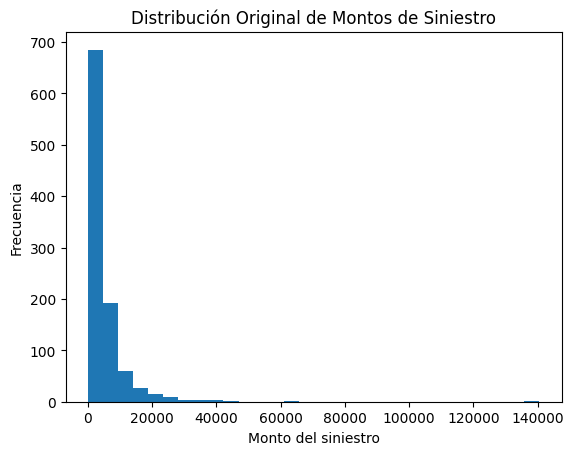

In [44]:
plt.hist(df["monto_siniestro"], bins=30)
plt.title("Distribución Original de Montos de Siniestro")
plt.xlabel("Monto del siniestro")
plt.ylabel("Frecuencia")
plt.show()

In [45]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

df["zscore"] = StandardScaler().fit_transform(
    df[["monto_siniestro"]]
)

df["minmax"] = MinMaxScaler().fit_transform(
    df[["monto_siniestro"]]
)

df["robust"] = RobustScaler().fit_transform(
    df[["monto_siniestro"]]
)

df[["zscore", "minmax", "robust"]].describe()

,zscore,minmax,robust
count,1.000000e+03,1000.000000,1.000000e+03
mean,1.953993e-17,0.034901,4.730320e-01
std,1.000500e+00,0.051955,1.761976e+00
min,-6.720934e-01,0.000000,-7.105879e-01
25%,-4.740541e-01,0.010284,-3.618220e-01
50%,-2.686011e-01,0.020953,5.496905e-17
75%,9.377467e-02,0.039770,6.381780e-01
max,1.858511e+01,1.000000,3.320317e+01


In [46]:
comparacion = pd.DataFrame({
    "Media": [
        df["monto_siniestro"].mean(),
        df["zscore"].mean(),
        df["minmax"].mean(),
        df["robust"].mean()
    ],
    "DesvStd": [
        df["monto_siniestro"].std(),
        df["zscore"].std(),
        df["minmax"].std(),
        df["robust"].std()
    ],
    "Mediana": [
        df["monto_siniestro"].median(),
        df["zscore"].median(),
        df["minmax"].median(),
        df["robust"].median()
    ]
},
index=["Original", "Z-Score", "Min-Max", "Robust"])

comparacion

,Media,DesvStd,Mediana
Original,5.014967e+03,7291.874310,3.057341e+03
Z-Score,1.953993e-17,1.000500,-2.686011e-01
Min-Max,3.490087e-02,0.051955,2.095279e-02
Robust,4.730320e-01,1.761976,5.491484e-17


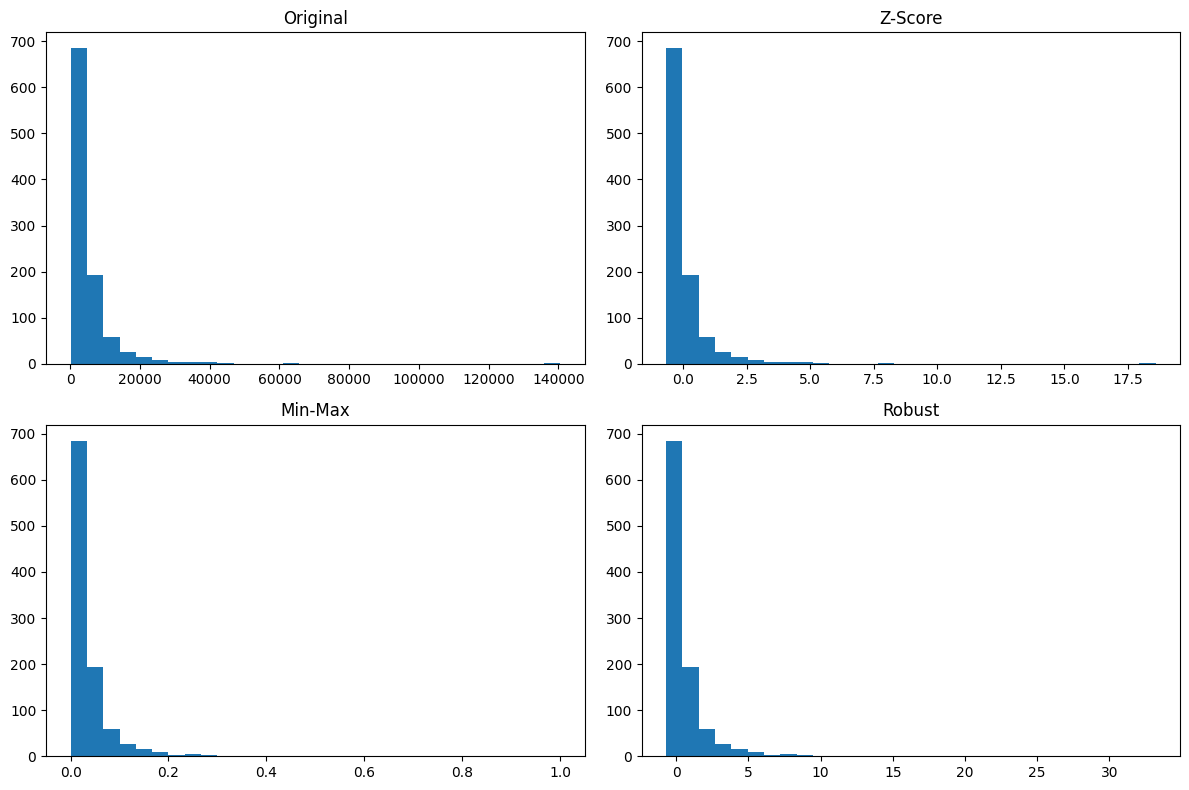

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(df["monto_siniestro"], bins=30)
axes[0,0].set_title("Original")

axes[0,1].hist(df["zscore"], bins=30)
axes[0,1].set_title("Z-Score")

axes[1,0].hist(df["minmax"], bins=30)
axes[1,0].set_title("Min-Max")

axes[1,1].hist(df["robust"], bins=30)
axes[1,1].set_title("Robust")

plt.tight_layout()
plt.show()

In [48]:
# Transformaciones

# Log, Box-Cox y Yeo-Johnson


df["log"] = np.log1p(df["monto_siniestro"])

df[["monto_siniestro", "log"]].describe()


,monto_siniestro,log
count,1000.000000,1000.000000
mean,5014.967437,8.019854
std,7291.874310,0.978729
min,116.598063,4.767273
25%,1559.953428,7.353051
50%,3057.341189,8.025628
75%,5698.418580,8.648119
max,140467.509325,11.852739


In [49]:
df[["monto_siniestro", "log"]].skew()

monto_siniestro    8.311086
log                0.118401
dtype: float64

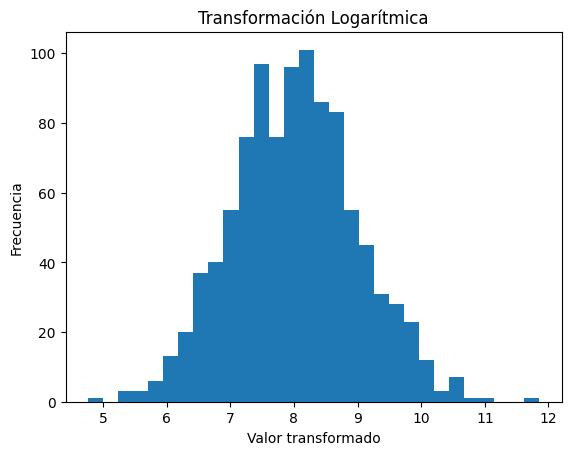

In [50]:
plt.hist(df["log"], bins=30)
plt.title("Transformación Logarítmica")
plt.xlabel("Valor transformado")
plt.ylabel("Frecuencia")
plt.show()

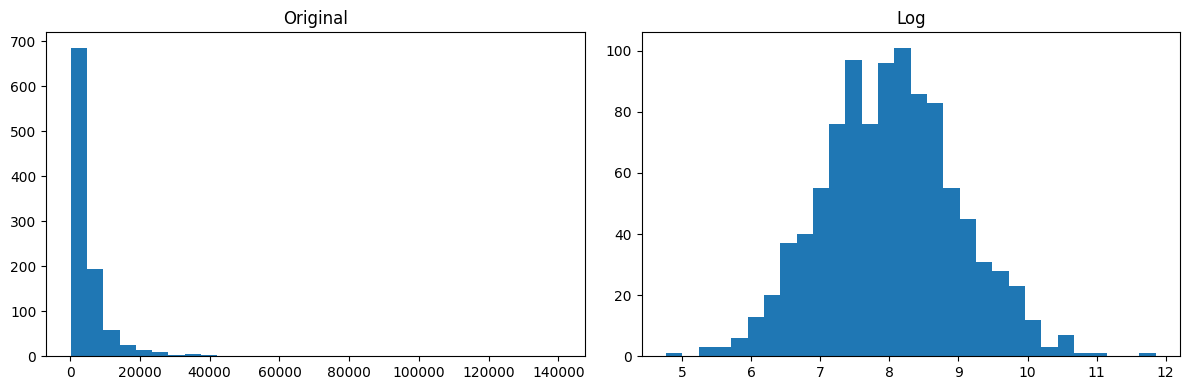

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(df["monto_siniestro"], bins=30)
axes[0].set_title("Original")

axes[1].hist(df["log"], bins=30)
axes[1].set_title("Log")

plt.tight_layout()
plt.show()

In [52]:
# Box-Cox

from scipy.stats import boxcox

df["boxcox"], lambda_boxcox = boxcox(
    df["monto_siniestro"]
)

print(lambda_boxcox)
df[["boxcox"]].skew()


-0.03911422470790534


boxcox   -0.000428
dtype: float64

In [53]:
df[["monto_siniestro", "boxcox"]].describe()

,monto_siniestro,boxcox
count,1000.000000,1000.000000
mean,5014.967437,6.869750
std,7291.874310,0.714774
min,116.598063,4.342097
25%,1559.953428,6.389652
50%,3057.341189,6.887786
75%,5698.418580,7.337188
max,140467.509325,9.484821


In [54]:
df[["monto_siniestro", "boxcox"]].skew()

monto_siniestro    8.311086
boxcox            -0.000428
dtype: float64

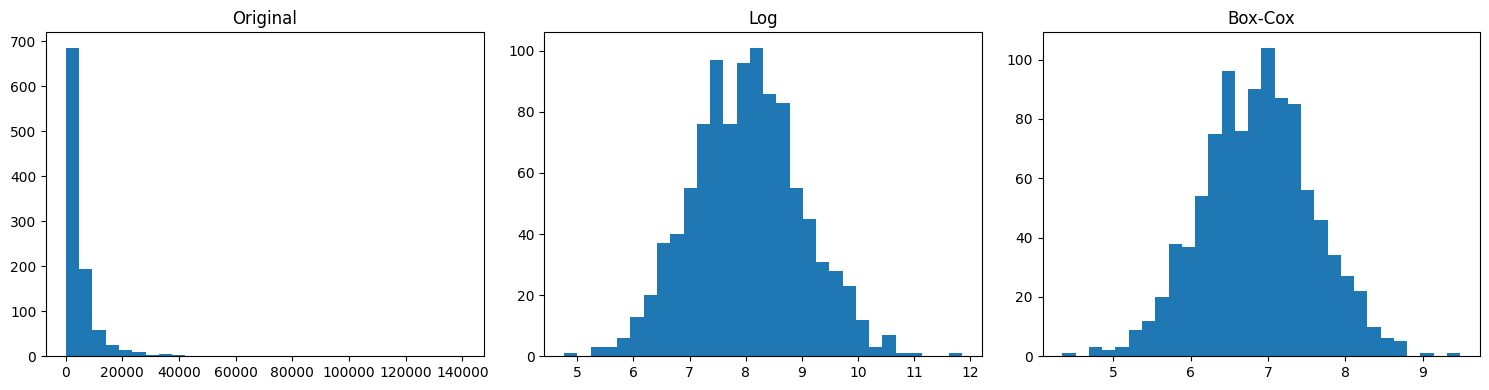

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(df["monto_siniestro"], bins=30)
axes[0].set_title("Original")

axes[1].hist(df["log"], bins=30)
axes[1].set_title("Log")

axes[2].hist(df["boxcox"], bins=30)
axes[2].set_title("Box-Cox")

plt.tight_layout()
plt.show()

In [56]:
# Yeo-Johnson

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df["yeojohnson"] = pt.fit_transform(
    df[["monto_siniestro"]]
)

df[["monto_siniestro", "yeojohnson"]].describe()

,monto_siniestro,yeojohnson
count,1000.000000,1.000000e+03
mean,5014.967437,2.566836e-16
std,7291.874310,1.000500e+00
min,116.598063,-3.533453e+00
25%,1559.953428,-6.721281e-01
50%,3057.341189,2.529478e-02
75%,5698.418580,6.544229e-01
max,140467.509325,3.658581e+00


In [57]:
df[["monto_siniestro", "yeojohnson"]].skew()

monto_siniestro    8.311086
yeojohnson        -0.000406
dtype: float64

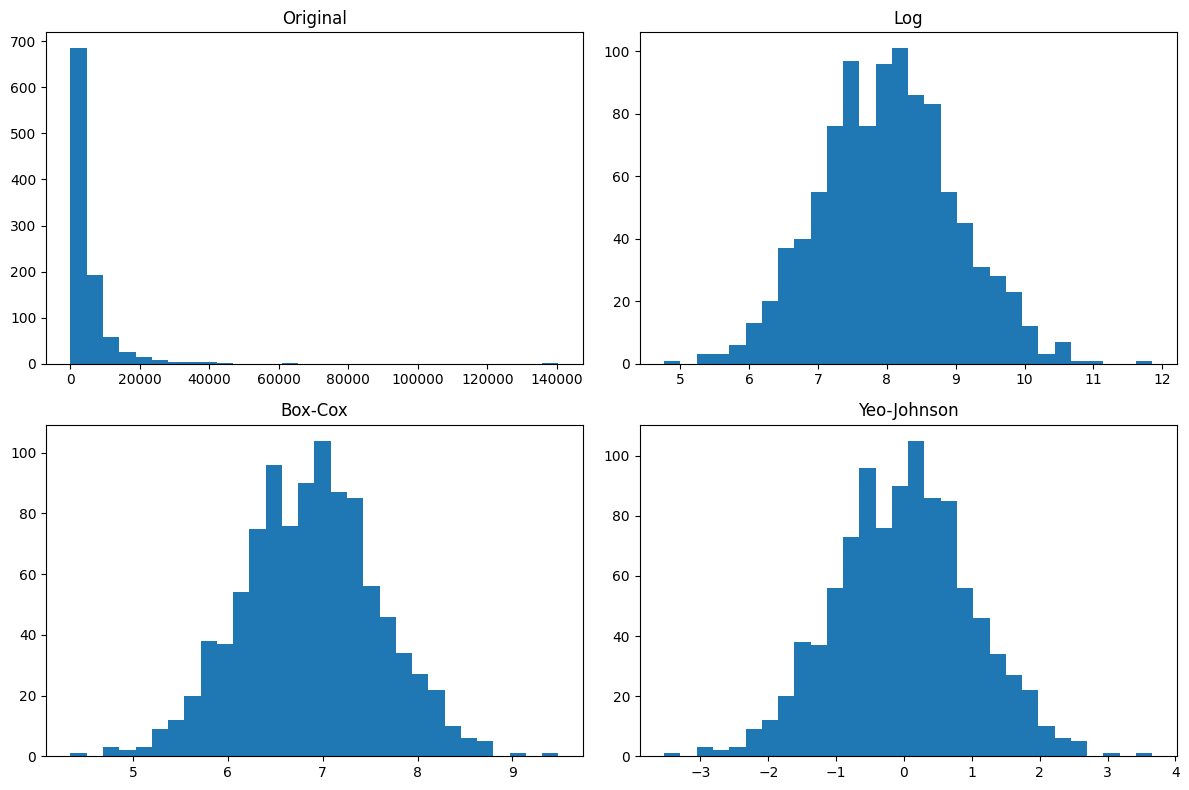

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(df["monto_siniestro"], bins=30)
axes[0,0].set_title("Original")

axes[0,1].hist(df["log"], bins=30)
axes[0,1].set_title("Log")

axes[1,0].hist(df["boxcox"], bins=30)
axes[1,0].set_title("Box-Cox")

axes[1,1].hist(df["yeojohnson"], bins=30)
axes[1,1].set_title("Yeo-Johnson")

plt.tight_layout()
plt.show()

In [59]:
df[
    [
        "monto_siniestro",
        "log",
        "boxcox",
        "yeojohnson"
    ]
].skew()

monto_siniestro    8.311086
log                0.118401
boxcox            -0.000428
yeojohnson        -0.000406
dtype: float64

In [60]:
conclusion = """
Conclusión

Al aplicar los métodos de escalamiento (Z-Score, Min-Max y Robust Scaling), se observó que los datos cambiaron de escala,
pero mantuvieron prácticamente la misma forma de distribución.
Los métodos resultan útiles para estandarizar variables, pero no para corregir el sesgo de la distribución.
Después al aplicar las transformaciones distributivas Log, Box-Cox y Yeo-Johnson, obutvimos;
1. la transformación logarítmica redujo la asimetría de 8.311 a 0.118, logrando una distribución mucho más simétrica.
2. Box-Cox obtuvo -0.000428
3. Y Yeo-Johnson obtuvo los mejores resultados -0.000406 valor muy cercano a cero.

Es decir, para los datos simulados de siniestros utilizados en este ejercicio, Box-Cox y Yeo-Johnson fueron las más efectivas,
dado a que aproximaron la distribución a un comportamiento cercano a la normalidad.
"""

print(conclusion)


Conclusión

Al aplicar los métodos de escalamiento (Z-Score, Min-Max y Robust Scaling), se observó que los datos cambiaron de escala,
pero mantuvieron prácticamente la misma forma de distribución.
Los métodos resultan útiles para estandarizar variables, pero no para corregir el sesgo de la distribución.
Después al aplicar las transformaciones distributivas Log, Box-Cox y Yeo-Johnson, obutvimos;
1. la transformación logarítmica redujo la asimetría de 8.311 a 0.118, logrando una distribución mucho más simétrica.
2. Box-Cox obtuvo -0.000428
3. Y Yeo-Johnson obtuvo los mejores resultados -0.000406 valor muy cercano a cero.

Es decir, para los datos simulados de siniestros utilizados en este ejercicio, Box-Cox y Yeo-Johnson fueron las más efectivas,
dado a que aproximaron la distribución a un comportamiento cercano a la normalidad.



---
## Parte 3 — Simulación de Variables Actuariales

Se simulan **10 años de datos mensuales** (2015–2024) para tres variables actuariales:
- **Exposición**: número de pólizas activas con tendencia creciente y estacionalidad anual.
- **Número de siniestros**: generado con distribución Poisson, cuya tasa es `Frecuencia × Exposición`.
- **Severidad**: costo promedio por siniestro, con inflación acumulada, estacionalidad y ciclo.

Cada variable contiene tres componentes temporales: **tendencia**, **estacionalidad** y **ciclo**.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

np.random.seed(42)
n_months = 120  # 10 años
t = np.arange(n_months)
fechas = pd.date_range('2015-01', periods=n_months, freq='ME')

# ── Exposición: tendencia lineal + estacionalidad anual + ruido
exposicion = 10_000 + 80*t + 500*np.sin(2*np.pi*t/12) + np.random.normal(0, 300, n_months)
exposicion = np.maximum(exposicion, 5_000)

# ── Frecuencia: tendencia leve + ciclo 36m + estacionalidad + ruido
ciclo_freq  = 0.008 * np.sin(2*np.pi*t/36 + 0.5)
estac_freq  = 0.003 * np.sin(2*np.pi*t/12)
tend_freq   = 0.0003 * t
frecuencia  = np.clip(0.05 + tend_freq + ciclo_freq + estac_freq
                      + np.random.normal(0, 0.002, n_months), 0.01, 0.20)

# ── Siniestros: Poisson con tasa = frecuencia * exposición
siniestros_n = np.random.poisson(frecuencia * exposicion)

# ── Severidad: inflación compuesta 0.3%/mes + ciclo 48m + estacionalidad
inflacion_acum = np.exp(0.003 * t)
ciclo_sev  = 300 * np.sin(2*np.pi*t/48)
estac_sev  = 150 * np.sin(2*np.pi*t/12 + 1)
severidad  = np.maximum(
    8_000 * inflacion_acum + ciclo_sev + estac_sev + np.random.normal(0, 400, n_months),
    3_000
)

# ── Frecuencia observada e índice de inflación
freq_obs  = siniestros_n / exposicion
inflac_idx = severidad / severidad[0]

df_ts = pd.DataFrame({
    'fecha':       fechas,
    'exposicion':  exposicion,
    'siniestros':  siniestros_n,
    'severidad':   severidad,
    'frecuencia':  freq_obs,
    'inflacion':   inflac_idx,
})
df_ts.set_index('fecha', inplace=True)
df_ts.head(10)


,exposicion,siniestros,severidad,frecuencia,inflacion
fecha,,,,,
2015-01-31,10149.014246,558,7731.930229,0.054981,1.000000
2015-02-28,10288.520710,592,8414.645460,0.057540,1.088298
2015-03-31,10787.319263,662,8046.984607,0.061368,1.040747
2015-04-30,11196.908957,619,7951.026217,0.055283,1.028337
2015-05-31,10682.766689,670,8210.843171,0.062718,1.061940
2015-06-30,10579.758913,702,7820.648402,0.066353,1.011474
2015-07-31,10953.763845,637,8009.755476,0.058154,1.035932
2015-08-31,10540.230419,599,7778.798298,0.056830,1.006062
2015-09-30,10066.144982,569,9106.722565,0.056526,1.177807


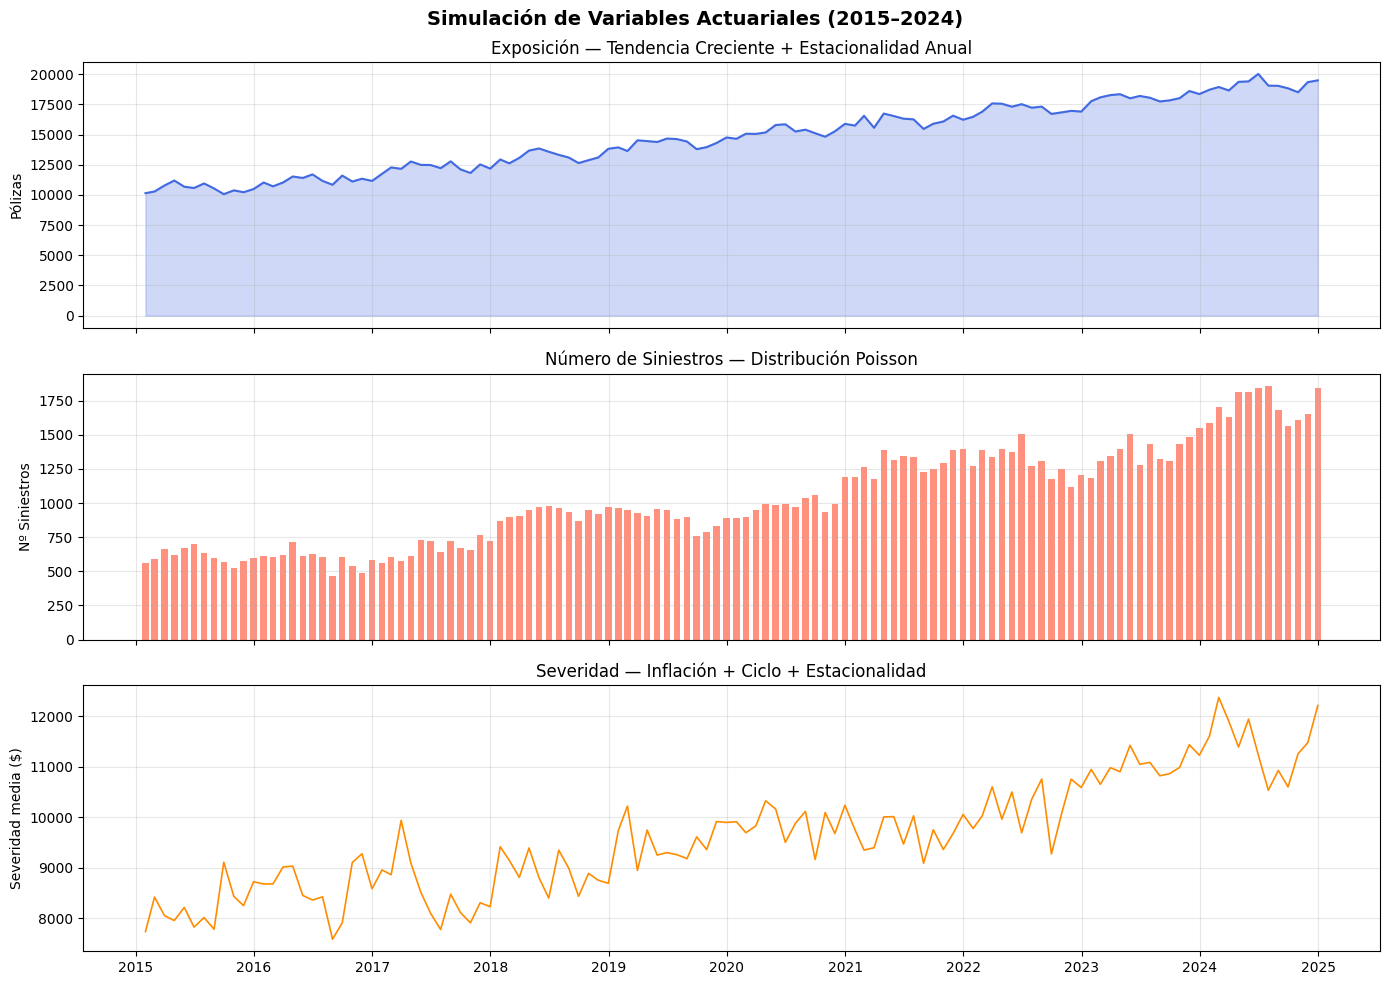

In [62]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Simulación de Variables Actuariales (2015–2024)', fontsize=14, fontweight='bold')

# Exposición
axes[0].fill_between(df_ts.index, df_ts['exposicion'], alpha=0.25, color='royalblue')
axes[0].plot(df_ts.index, df_ts['exposicion'], color='royalblue', lw=1.5)
axes[0].set_ylabel('Pólizas')
axes[0].set_title('Exposición — Tendencia Creciente + Estacionalidad Anual')
axes[0].grid(True, alpha=0.3)

# Siniestros
axes[1].bar(df_ts.index, df_ts['siniestros'], color='tomato', alpha=0.7, width=20)
axes[1].set_ylabel('Nº Siniestros')
axes[1].set_title('Número de Siniestros — Distribución Poisson')
axes[1].grid(True, alpha=0.3)

# Severidad
axes[2].plot(df_ts.index, df_ts['severidad'], color='darkorange', lw=1.2, label='Severidad')
axes[2].set_ylabel('Severidad media ($)')
axes[2].set_title('Severidad — Inflación + Ciclo + Estacionalidad')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


---
## Parte 4 — Ciclos mediante Senos y Cosenos

Se ajusta un **modelo armónico** por regresión lineal para capturar el ciclo en cada serie:

$$y(t) = a_0 + a_1 \cdot t + b \cdot \sin\!\left(\frac{2\pi t}{T}\right) + c \cdot \cos\!\left(\frac{2\pi t}{T}\right)$$

- **Frecuencia**: período T = 36 meses (ciclo trienal del mercado asegurador)
- **Inflación**: período T = 48 meses (ciclo cuatrienal de costos)

In [63]:
def ciclo_armonico(serie, periodo):
    """Ajuste armónico: tendencia + seno + coseno"""
    sin_c = np.sin(2 * np.pi * t / periodo)
    cos_c = np.cos(2 * np.pi * t / periodo)
    A = np.column_stack([np.ones(n_months), t, sin_c, cos_c])
    coef, *_ = np.linalg.lstsq(A, serie, rcond=None)
    ajuste = A @ coef
    return ajuste, coef

ciclo_freq_fit, coef_freq = ciclo_armonico(df_ts['frecuencia'].values, 36)
ciclo_infl_fit, coef_infl = ciclo_armonico(df_ts['inflacion'].values, 48)

print('Coeficientes — Frecuencia [a0, a1 (tend), b (sin), c (cos)]:')
print([f'{v:.6f}' for v in coef_freq])
print()
print('Coeficientes — Inflación  [a0, a1 (tend), b (sin), c (cos)]:')
print([f'{v:.6f}' for v in coef_infl])


Coeficientes — Frecuencia [a0, a1 (tend), b (sin), c (cos)]:
['0.049907', '0.000300', '0.007151', '0.003638']

Coeficientes — Inflación  [a0, a1 (tend), b (sin), c (cos)]:
['1.016203', '0.003692', '0.043137', '0.002891']


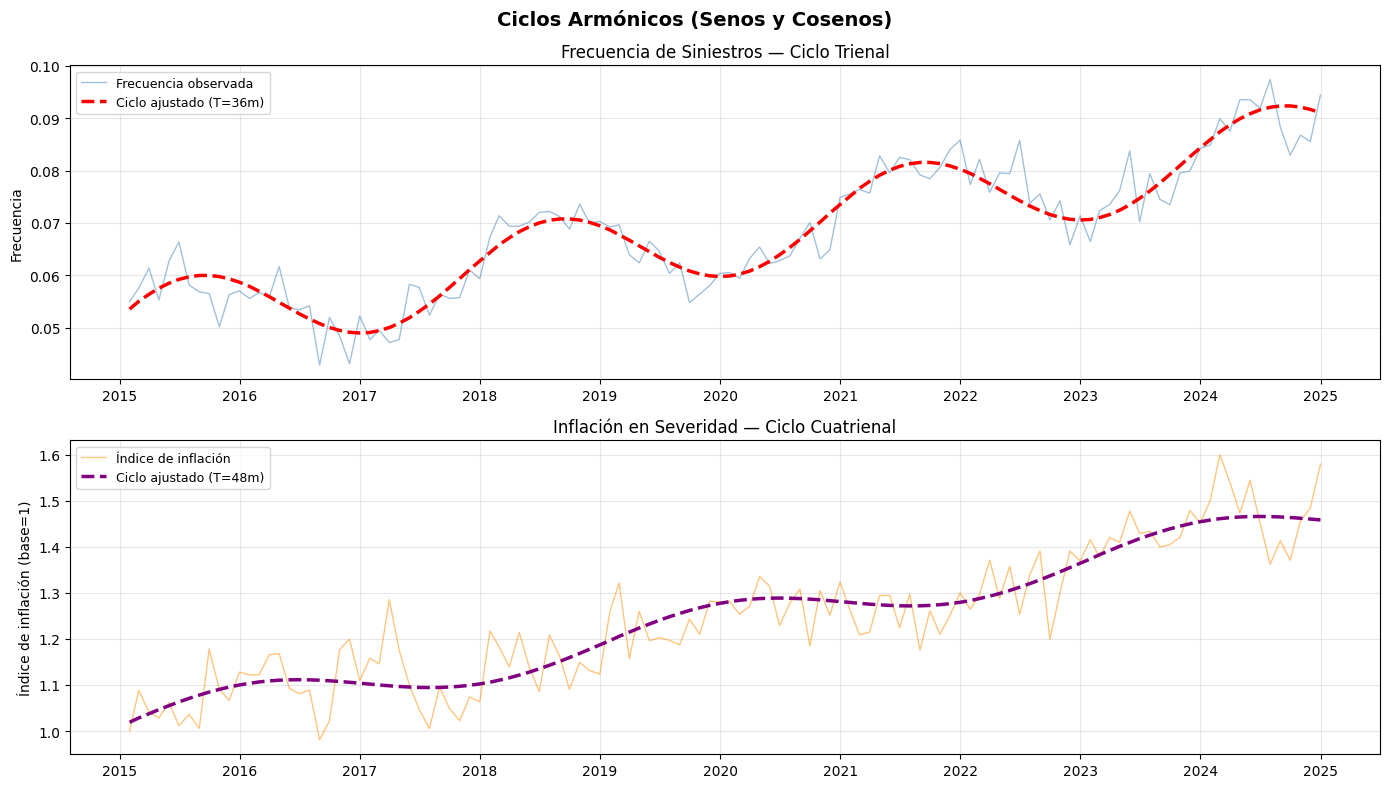

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Ciclos Armónicos (Senos y Cosenos)', fontsize=14, fontweight='bold')

# Frecuencia
axes[0].plot(df_ts.index, df_ts['frecuencia'], color='steelblue', lw=1, alpha=0.5, label='Frecuencia observada')
axes[0].plot(df_ts.index, ciclo_freq_fit, color='red', lw=2.5, ls='--', label='Ciclo ajustado (T=36m)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Frecuencia de Siniestros — Ciclo Trienal')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Inflación
axes[1].plot(df_ts.index, df_ts['inflacion'], color='darkorange', lw=1, alpha=0.5, label='Índice de inflación')
axes[1].plot(df_ts.index, ciclo_infl_fit, color='purple', lw=2.5, ls='--', label='Ciclo ajustado (T=48m)')
axes[1].set_ylabel('Índice de inflación (base=1)')
axes[1].set_title('Inflación en Severidad — Ciclo Cuatrienal')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


---
## Parte 5 — Medias Móviles de Frecuencia y Severidad

Las medias móviles suavizan las fluctuaciones y revelan la tendencia subyacente.
Se calculan ventanas de **3 meses** (sensible a cambios recientes) y **12 meses** (elimina la estacionalidad anual).

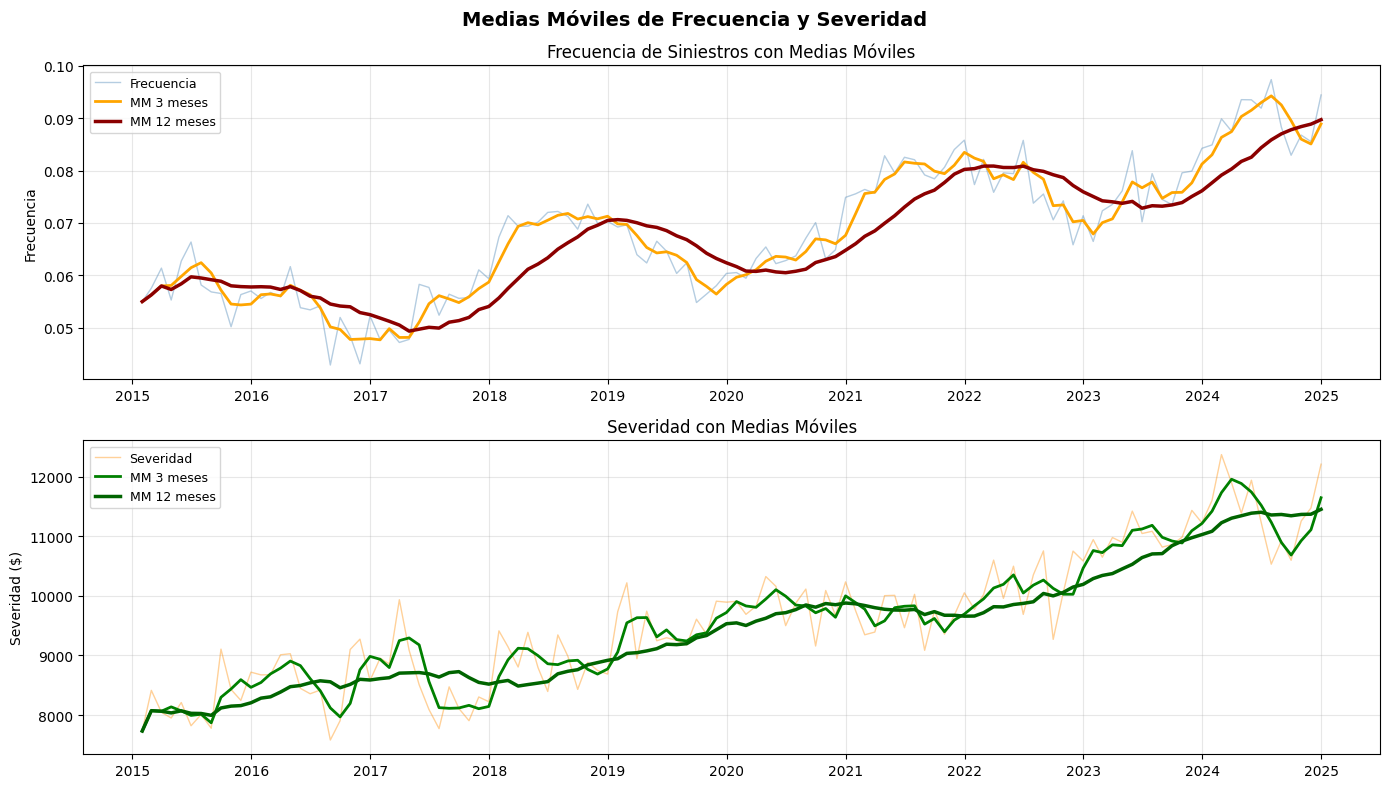


    Conclusion

      La severidad de los siniestros muestra una tendencia al alza durante todo el periodo analizado, 
      lo cual refleja el impacto de la inflación incluida en la simulación. La media móvil de 3 meses ayuda a 
      suavizar las variaciones de corto plazo, mientras que la de 12 meses permite observar con mayor claridad 
      la evolución a largo plazo. En general, se aprecia un crecimiento constante en el monto promedio de los 
      siniestros, lo que indica que los costos asociados aumentan progresivamente con el tiempo. El uso de medias móviles 
      facilita identificar esta tendencia al reducir la variabilidad mensual y el ruido presente en la serie original.

      


In [65]:
# ── Medias móviles
df_ts['freq_mm3']  = df_ts['frecuencia'].rolling(3,  center=False, min_periods=1).mean()
df_ts['freq_mm12'] = df_ts['frecuencia'].rolling(12, center=False, min_periods=1).mean()
df_ts['sev_mm3']   = df_ts['severidad'].rolling(3,   center=False, min_periods=1).mean()
df_ts['sev_mm12']  = df_ts['severidad'].rolling(12,  center=False, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Medias Móviles de Frecuencia y Severidad', fontsize=14, fontweight='bold')

# Frecuencia + MM
axes[0].plot(df_ts.index, df_ts['frecuencia'], color='steelblue',  lw=1,   alpha=0.4, label='Frecuencia')
axes[0].plot(df_ts.index, df_ts['freq_mm3'],   color='orange',     lw=2,   label='MM 3 meses')
axes[0].plot(df_ts.index, df_ts['freq_mm12'],  color='darkred',    lw=2.5, label='MM 12 meses')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Frecuencia de Siniestros con Medias Móviles')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Severidad + MM
axes[1].plot(df_ts.index, df_ts['severidad'], color='darkorange', lw=1,   alpha=0.4, label='Severidad')
axes[1].plot(df_ts.index, df_ts['sev_mm3'],   color='green',     lw=2,   label='MM 3 meses')
axes[1].plot(df_ts.index, df_ts['sev_mm12'],  color='darkgreen', lw=2.5, label='MM 12 meses')
axes[1].set_ylabel('Severidad ($)')
axes[1].set_title('Severidad con Medias Móviles')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


print('''
    Conclusion
      
      La severidad de los siniestros muestra una tendencia al alza durante todo el periodo analizado, 
      lo cual refleja el impacto de la inflación incluida en la simulación. La media móvil de 3 meses ayuda a 
      suavizar las variaciones de corto plazo, mientras que la de 12 meses permite observar con mayor claridad 
      la evolución a largo plazo. En general, se aprecia un crecimiento constante en el monto promedio de los 
      siniestros, lo que indica que los costos asociados aumentan progresivamente con el tiempo. El uso de medias móviles 
      facilita identificar esta tendencia al reducir la variabilidad mensual y el ruido presente en la serie original.

      ''')

In [66]:
import subprocess, sys

print('Instalando reportlab...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'reportlab', '-q'])
print('reportlab instalado correctamente.')


Instalando reportlab...
reportlab instalado correctamente.


---
## Parte 6 — Exportar a PDF

Esta celda genera el PDF usando **`reportlab`** directamente, sin LaTeX ni nbconvert.

**Flujo:**
1. Re-genera cada figura en un buffer en memoria (`io.BytesIO`)
2. `reportlab` arma el PDF con portada, secciones, imágenes y conclusiones
3. El archivo queda en el mismo directorio del notebook

> Ejecutar **después** de haber corrido todas las celdas anteriores.

In [67]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from scipy.stats import boxcox
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                Image, HRFlowable, PageBreak, Table, TableStyle)

# ═══════════════════════════════════════════════════════════════
# BLOQUE 1 — Recrear datos de escalamiento y transformaciones
# ═══════════════════════════════════════════════════════════════
np.random.seed(42)
siniestros = np.random.lognormal(mean=8, sigma=1, size=1000)
df = pd.DataFrame({'monto_siniestro': siniestros})
df['zscore']     = StandardScaler().fit_transform(df[['monto_siniestro']])
df['minmax']     = MinMaxScaler().fit_transform(df[['monto_siniestro']])
df['robust']     = RobustScaler().fit_transform(df[['monto_siniestro']])
df['log']        = np.log1p(df['monto_siniestro'])
df['boxcox'], lambda_boxcox = boxcox(df['monto_siniestro'])
pt = PowerTransformer(method='yeo-johnson')
df['yeojohnson'] = pt.fit_transform(df[['monto_siniestro']])

# ═══════════════════════════════════════════════════════════════
# BLOQUE 2 — Recrear simulación temporal
# ═══════════════════════════════════════════════════════════════
n_months = 120
t = np.arange(n_months)
fechas = pd.date_range('2015-01', periods=n_months, freq='ME')

exposicion   = np.maximum(10_000 + 80*t + 500*np.sin(2*np.pi*t/12)
                          + np.random.normal(0, 300, n_months), 5_000)
frecuencia   = np.clip(0.05 + 0.0003*t
                       + 0.008*np.sin(2*np.pi*t/36 + 0.5)
                       + 0.003*np.sin(2*np.pi*t/12)
                       + np.random.normal(0, 0.002, n_months), 0.01, 0.20)
siniestros_n = np.random.poisson(frecuencia * exposicion)
severidad    = np.maximum(
    8_000*np.exp(0.003*t)
    + 300*np.sin(2*np.pi*t/48)
    + 150*np.sin(2*np.pi*t/12 + 1)
    + np.random.normal(0, 400, n_months), 3_000)

freq_obs   = siniestros_n / exposicion
inflac_idx = severidad / severidad[0]

df_ts = pd.DataFrame({
    'exposicion': exposicion, 'siniestros': siniestros_n,
    'severidad':  severidad,  'frecuencia': freq_obs,
    'inflacion':  inflac_idx,
}, index=fechas)

df_ts['freq_mm3']  = df_ts['frecuencia'].rolling(3,  center=True, min_periods=1).mean()
df_ts['freq_mm12'] = df_ts['frecuencia'].rolling(12, center=True, min_periods=1).mean()
df_ts['sev_mm3']   = df_ts['severidad'].rolling(3,   center=True, min_periods=1).mean()
df_ts['sev_mm12']  = df_ts['severidad'].rolling(12,  center=True, min_periods=1).mean()

# ═══════════════════════════════════════════════════════════════
# BLOQUE 3 — Ciclos armónicos
# ═══════════════════════════════════════════════════════════════
def ciclo_armonico(serie, periodo):
    A = np.column_stack([np.ones(n_months), t,
                         np.sin(2*np.pi*t/periodo),
                         np.cos(2*np.pi*t/periodo)])
    coef, *_ = np.linalg.lstsq(A, serie, rcond=None)
    return A @ coef

ciclo_freq_fit = ciclo_armonico(df_ts['frecuencia'].values, 36)
ciclo_infl_fit = ciclo_armonico(df_ts['inflacion'].values,  48)

print('Datos recreados correctamente.')

# ═══════════════════════════════════════════════════════════════
# BLOQUE 4 — Generar figuras en memoria
# ═══════════════════════════════════════════════════════════════
def fig_to_buf(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf

# Fig 1 — Escalamiento
fig1, axes = plt.subplots(2, 2, figsize=(11, 7))
fig1.suptitle('Métodos de Escalamiento', fontsize=13, fontweight='bold')
for ax, col, title, c in zip(axes.flatten(),
        ['monto_siniestro','zscore','minmax','robust'],
        ['Original','Z-Score','Min-Max','Robust'],
        ['steelblue','darkorange','mediumseagreen','mediumpurple']):
    ax.hist(df[col], bins=35, color=c, edgecolor='white', lw=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
fig1.tight_layout(); buf1 = fig_to_buf(fig1)

# Fig 2 — Transformaciones
fig2, axes = plt.subplots(2, 2, figsize=(11, 7))
fig2.suptitle('Transformaciones de Distribución', fontsize=13, fontweight='bold')
labels_tr = [f"Original  (sesgo={df['monto_siniestro'].skew():.2f})",
             f"Log  (sesgo={df['log'].skew():.3f})",
             f"Box-Cox  (sesgo={df['boxcox'].skew():.4f})",
             f"Yeo-Johnson  (sesgo={df['yeojohnson'].skew():.4f})"]
for ax, col, title, c in zip(axes.flatten(),
        ['monto_siniestro','log','boxcox','yeojohnson'],
        labels_tr,
        ['steelblue','darkorange','mediumseagreen','mediumpurple']):
    ax.hist(df[col], bins=35, color=c, edgecolor='white', lw=0.4)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Valor transformado'); ax.set_ylabel('Frecuencia')
fig2.tight_layout(); buf2 = fig_to_buf(fig2)

# Fig 3 — Simulación
fig3, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig3.suptitle('Simulación de Variables Actuariales (2015–2024)', fontsize=13, fontweight='bold')
axes[0].fill_between(df_ts.index, df_ts['exposicion'], alpha=0.25, color='royalblue')
axes[0].plot(df_ts.index, df_ts['exposicion'], color='royalblue', lw=1.5)
axes[0].set_ylabel('Pólizas'); axes[0].set_title('Exposición'); axes[0].grid(True, alpha=0.3)
axes[1].bar(df_ts.index, df_ts['siniestros'], color='tomato', alpha=0.7, width=20)
axes[1].set_ylabel('Nº Siniestros'); axes[1].set_title('Número de Siniestros'); axes[1].grid(True, alpha=0.3)
axes[2].plot(df_ts.index, df_ts['severidad'], color='darkorange', lw=1.2)
axes[2].set_ylabel('Severidad ($)'); axes[2].set_title('Severidad'); axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig3.tight_layout(); buf3 = fig_to_buf(fig3)

# Fig 4 — Ciclos
fig4, axes = plt.subplots(2, 1, figsize=(13, 7))
fig4.suptitle('Ciclos Armónicos (Senos y Cosenos)', fontsize=13, fontweight='bold')
axes[0].plot(df_ts.index, df_ts['frecuencia'], color='steelblue', lw=1, alpha=0.5, label='Observada')
axes[0].plot(df_ts.index, ciclo_freq_fit, color='red', lw=2.5, ls='--', label='Ciclo T=36m')
axes[0].set_ylabel('Frecuencia'); axes[0].set_title('Frecuencia — Ciclo Trienal')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].plot(df_ts.index, df_ts['inflacion'], color='darkorange', lw=1, alpha=0.5, label='Observada')
axes[1].plot(df_ts.index, ciclo_infl_fit, color='purple', lw=2.5, ls='--', label='Ciclo T=48m')
axes[1].set_ylabel('Índice'); axes[1].set_title('Inflación — Ciclo Cuatrienal')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig4.tight_layout(); buf4 = fig_to_buf(fig4)

# Fig 5 — Medias móviles
fig5, axes = plt.subplots(2, 1, figsize=(13, 7))
fig5.suptitle('Medias Móviles de Frecuencia y Severidad', fontsize=13, fontweight='bold')
axes[0].plot(df_ts.index, df_ts['frecuencia'], color='steelblue', lw=1, alpha=0.4, label='Frecuencia')
axes[0].plot(df_ts.index, df_ts['freq_mm3'],   color='orange',   lw=2,   label='MM 3m')
axes[0].plot(df_ts.index, df_ts['freq_mm12'],  color='darkred',  lw=2.5, label='MM 12m')
axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].plot(df_ts.index, df_ts['severidad'],  color='darkorange', lw=1, alpha=0.4, label='Severidad')
axes[1].plot(df_ts.index, df_ts['sev_mm3'],    color='green',     lw=2,   label='MM 3m')
axes[1].plot(df_ts.index, df_ts['sev_mm12'],   color='darkgreen', lw=2.5, label='MM 12m')
axes[1].set_ylabel('Severidad ($)'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig5.tight_layout(); buf5 = fig_to_buf(fig5)

print('Figuras generadas en memoria.')

# ═══════════════════════════════════════════════════════════════
# BLOQUE 5 — Construir el PDF
# ═══════════════════════════════════════════════════════════════
SS   = getSampleStyleSheet()
BLUE = colors.HexColor('#1a3a6b')
GRAY = colors.HexColor('#e8ecf0')

def sty(base, **kw):
    s = SS[base].clone(base + '_c')
    for k, v in kw.items(): setattr(s, k, v)
    return s

s_title = sty('Title',   fontSize=17, textColor=BLUE, spaceAfter=6)
s_sub   = sty('Normal',  fontSize=12, alignment=TA_CENTER,
               textColor=colors.HexColor('#2c5f8a'), spaceAfter=10)
s_h1    = sty('Heading1',fontSize=12, textColor=BLUE, spaceBefore=12, spaceAfter=4)
s_body  = sty('Normal',  fontSize=9.5, leading=13, alignment=TA_JUSTIFY, spaceAfter=5)
s_cap   = sty('Normal',  fontSize=8,  textColor=colors.HexColor('#666666'),
               alignment=TA_CENTER, spaceAfter=8)
s_bul   = sty('Normal',  fontSize=9.5, leading=13, leftIndent=14, spaceAfter=3)

def hr():
    return HRFlowable(width='100%', thickness=0.5,
                      color=colors.HexColor('#bbbbbb'), spaceAfter=6)
def im(buf, w=6.0):
    buf.seek(0)
    return Image(buf, width=w*inch, height=w*0.60*inch, kind='proportional')

story = []

# Portada
story += [Spacer(1, 0.5*inch),
          Paragraph('Escalamiento y Transformación de Datos', s_title),
          Paragraph('Simulación de Variables Actuariales', s_sub), hr(),
          Spacer(1, 0.15*inch)]
integ = [['Integrantes del Equipo',''],
         ['Nombre 1:','________________________________'],
         ['Nombre 2:','________________________________'],
         ['Nombre 3:','________________________________'],
         ['Nombre 4:','________________________________'],
         ['Nombre 5:','________________________________'],
         ['Nombre 6:','Ismael Ruiz Carbajal'],


         ['Fecha:','Mayo 2026']]
ti = Table(integ, colWidths=[1.5*inch, 4.2*inch])
ti.setStyle(TableStyle([
    ('SPAN',(0,0),(1,0)),('BACKGROUND',(0,0),(1,0),BLUE),
    ('TEXTCOLOR',(0,0),(1,0),colors.white),
    ('FONTNAME',(0,0),(1,0),'Helvetica-Bold'),('FONTSIZE',(0,0),(1,0),11),
    ('ALIGN',(0,0),(1,0),'CENTER'),
    ('FONTNAME',(0,1),(0,-1),'Helvetica-Bold'),('FONTSIZE',(0,1),(1,-1),9.5),
    ('ROWBACKGROUNDS',(0,1),(1,-1),[colors.white,GRAY]),
    ('BOTTOMPADDING',(0,0),(1,-1),5),('TOPPADDING',(0,0),(1,-1),5),
    ('LEFTPADDING',(0,0),(1,-1),8),
    ('GRID',(0,0),(1,-1),0.3,colors.HexColor('#cccccc'))]))
story += [ti, PageBreak()]

# Sección 1
story += [Paragraph('1. Métodos de Escalamiento', s_h1), hr(),
    Paragraph('Se simularon 1,000 montos de siniestros con distribución lognormal. '
              'Los tres métodos cambian la escala pero no la forma de la distribución.', s_body),
    Paragraph('• <b>Z-Score:</b> media=0, desv.std=1. Sensible a outliers.', s_bul),
    Paragraph('• <b>Min-Max:</b> rango [0,1].', s_bul),
    Paragraph('• <b>Robust:</b> usa mediana e IQR. Resistente a valores extremos.', s_bul),
    Spacer(1, 0.1*inch), im(buf1),
    Paragraph('Figura 1. Histogramas comparativos de los métodos de escalamiento.', s_cap),
    Paragraph('<b>Conclusión:</b> El sesgo se mantiene en 8.31 en los tres casos. '
              'El escalamiento no corrige la asimetría; solo reescala.', s_body),
    PageBreak()]

# Sección 2
story += [Paragraph('2. Transformaciones de Distribución', s_h1), hr(),
    Paragraph('Las transformaciones modifican la forma de la distribución, reduciendo la asimetría.', s_body),
    Paragraph('• <b>Logarítmica:</b> sesgo de 8.31 → 0.118.', s_bul),
    Paragraph(f'• <b>Box-Cox (lambda={lambda_boxcox:.4f}):</b> sesgo resultante ≈ 0.0004.', s_bul),
    Paragraph('• <b>Yeo-Johnson:</b> sesgo resultante ≈ 0.0004. Acepta ceros y negativos.', s_bul),
    Spacer(1, 0.1*inch), im(buf2),
    Paragraph('Figura 2. Comparación de transformaciones distribucionales.', s_cap),
    Paragraph('<b>Conclusión:</b> Box-Cox y Yeo-Johnson logran una reducción del sesgo del 99.99%.', s_body),
    PageBreak()]

# Sección 3
story += [Paragraph('3. Simulación de Variables Actuariales', s_h1), hr(),
    Paragraph('Se simularon 10 años de datos mensuales (2015–2024) con tendencia, '
              'estacionalidad anual y ciclos en cada variable.', s_body),
    Paragraph('• <b>Exposición:</b> tendencia lineal +80 pólizas/mes + estacionalidad anual.', s_bul),
    Paragraph('• <b>Siniestros:</b> Poisson con tasa = Frecuencia × Exposición.', s_bul),
    Paragraph('• <b>Severidad:</b> inflación 0.3%/mes + ciclo 48 meses + estacionalidad.', s_bul),
    Spacer(1, 0.1*inch), im(buf3, w=6.3),
    Paragraph('Figura 3. Simulación de Exposición, Siniestros y Severidad.', s_cap),
    PageBreak()]

# Sección 4
story += [Paragraph('4. Ciclos mediante Senos y Cosenos', s_h1), hr(),
    Paragraph('Modelo ajustado: y(t) = a0 + a1·t + b·sin(2πt/T) + c·cos(2πt/T)', s_body),
    Paragraph('• <b>Frecuencia:</b> ciclo T=36 meses (ciclo trienal del mercado asegurador).', s_bul),
    Paragraph('• <b>Inflación:</b> ciclo T=48 meses (ciclo cuatrienal macroeconómico).', s_bul),
    Spacer(1, 0.1*inch), im(buf4, w=6.3),
    Paragraph('Figura 4. Ciclos armónicos en Frecuencia e Inflación.', s_cap),
    Paragraph('<b>Conclusión:</b> La descomposición armónica cuantifica amplitud y fase del ciclo, '
              'útil para pricing y reservas técnicas.', s_body),
    PageBreak()]

# Sección 5
story += [Paragraph('5. Medias Móviles de Frecuencia y Severidad', s_h1), hr(),
    Paragraph('MM 3 meses: sensible a cambios recientes. '
              'MM 12 meses: elimina la estacionalidad y revela la tendencia real.', s_body),
    Spacer(1, 0.1*inch), im(buf5, w=6.3),
    Paragraph('Figura 5. Medias móviles de Frecuencia y Severidad.', s_cap),
    Paragraph('<b>Conclusión:</b> La MM 12m es clave para aislar la tendencia real de frecuencia '
              'e inflación en el análisis de portafolio.', s_body),
    PageBreak()]

# Conclusiones
story += [Paragraph('Conclusiones Generales', s_h1), hr(),
    Paragraph('• <b>Escalamiento vs Transformación:</b> el escalamiento no modifica la forma '
              'distribucional; Log/Box-Cox/Yeo-Johnson sí reducen la asimetría.', s_bul),
    Paragraph('• <b>Componentes temporales:</b> la simulación identifica tendencia, estacionalidad '
              'y ciclos de forma controlada.', s_bul),
    Paragraph('• <b>Ciclos armónicos:</b> permiten cuantificar el ciclo del mercado asegurador.', s_bul),
    Paragraph('• <b>Medias móviles:</b> la MM 12m es esencial para el análisis de tendencias '
              'de frecuencia e inflación en portafolios de seguros.', s_bul),
    Spacer(1, 0.2*inch), hr(),
    Paragraph('Herramientas: Python · NumPy · Pandas · SciPy · Scikit-learn · Matplotlib · ReportLab',
              sty('Normal', fontSize=8, textColor=colors.HexColor('#888888'), alignment=TA_CENTER))]

pdf_path = 'actividad_escalamiento_transformaciones.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=letter,
    leftMargin=0.9*inch, rightMargin=0.9*inch,
    topMargin=0.8*inch,  bottomMargin=0.8*inch)
doc.build(story)
print(f'PDF generado: {pdf_path}')


Datos recreados correctamente.
Figuras generadas en memoria.
PDF generado: actividad_escalamiento_transformaciones.pdf


In [68]:
import os
print(os.path.abspath('actividad_escalamiento_transformaciones.pdf'))

c:\Users\melgo\OneDrive\Documentos\DIPLOMADO\ml-insurance-team-lab\actividad_escalamiento_transformaciones.pdf
